In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from pathlib import Path

In [ ]:
BASE = Path(".")
NB4 = BASE / "nb4"
NB5 = BASE / "nb5"

#INPUTS
HUMAN_GT = NB5 / "Human Annotation_Final.csv"
MODEL_PRED = NB5 / "sample_predictions.xlsx"
SLGAD_SCORE = NB4 / "slgad_review_scores.csv"
FULL_DATA = NB5 / "final_predictions.csv"


In [ ]:
scores = pd.read_csv(SLGAD_SCORE)
full_data = pd.read_csv(FULL_DATA)
sample_data = pd.read_excel(MODEL_PRED)
ha   = pd.read_csv(HUMAN_GT)

In [ ]:
final_with_score = full_data.merge(scores, on="review_id", how="left")
sample_reset = ha.reset_index().rename(columns={"index": "sample_row"})
merged = sample_reset.merge(
    final_with_score,
    on=["rating", "title", "text"],
    how="left",
    suffixes=("_sample", "_full"),
)

In [ ]:
best_match = (
    merged
    .sort_values(["sample_row", "anomaly_score"], ascending=[True, False])
    .groupby("sample_row")
    .head(1)
)


print("best_match:", best_match.shape)

best_match: (700, 49)


In [ ]:
best_match

,sample_row,rating,title,text,unique_id,id,is_fake,reasoning_en,asin,parent_asin,...,review_id,anomaly,user_suspicious,pseudo_label,final_label,pred_label,p_genuine,p_fake,label_source,anomaly_score
0,0,5,Definitely Recommend!,"Jordans, Air Force 1 friendly! Love my shoes b...",0,0,1,"The review includes a small amount of detail, ...",B0BG1Q7K1G,B0BFGT95XL,...,r_5447,0.044048,0,-1,1,1,3.716930e-05,9.999628e-01,self_train,0.044048
1,1,5,Great With Jeans Or Other Casual Pants,This is not a belt to wear with a business or ...,1,1,0,The review mentions specific fit/size details ...,B010R95A12,B010R95A12,...,r_5682,0.039201,0,-1,0,0,1.000000e+00,3.078784e-37,self_train,0.039201
2,2,5,Five Stars,Very spacious and stylish. Goes with everything.,2,2,1,Very short and dominated by generic praise wit...,B00ZBFR1ZQ,B00ZBFR1ZQ,...,r_5828,0.032518,0,-1,1,1,4.359521e-02,9.564048e-01,self_train,0.032518
3,3,5,Nice socks!,These are cute and I like them a lot. I take a...,3,3,1,"The review includes a small amount of detail, ...",B01N7HPLON,B01N7HPLON,...,r_2394,0.035354,0,-1,1,1,7.977743e-09,1.000000e+00,self_train,0.035354
4,4,3,... this would be tshirt material and it was m...,I thought this would be tshirt material and it...,4,4,1,"The review includes a small amount of detail, ...",B01M9A79QJ,B01M9A79QJ,...,r_5600,0.048710,0,-1,1,1,1.001538e-13,1.000000e+00,self_train,0.048710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
775,695,5,Very pretty,I liked all the crystals on this watch. It mad...,695,695,0,There are concrete details about fit/size and ...,B08JZ39Q11,B08JZ39Q11,...,r_195,0.042822,0,-1,0,0,1.000000e+00,2.533850e-39,self_train,0.042822
776,696,5,Great fit and seal,My daughter loves them and we’re waiting for t...,696,696,0,There are concrete details about fit/size and ...,B074PMQBLP,B074PMQBLP,...,r_2295,0.043714,0,-1,0,0,1.000000e+00,2.199717e-10,self_train,0.043714
777,697,4,Four Stars,Very pretty ring !,697,697,1,Very short and dominated by generic praise wit...,B00KPXV0G0,B07CKBBWBC,...,r_6454,0.042199,0,-1,0,0,9.999999e-01,1.100991e-07,self_train,0.042199
778,698,1,Runs Small - Contains Cancer Chemicals,Runs Small<br />My normal shirt size is a xs/s...,698,698,0,The review mentions specific fit/size details ...,B07YNW4D99,B07YNW4D99,...,r_1465,0.095007,0,-1,0,0,9.999993e-01,7.408874e-07,self_train,0.095007


# SLGAD RESULTS

In [ ]:
threshold = best_match["anomaly"].quantile(0.95)
print("Quantile 0.9 threshold:", threshold)


Quantile 0.9 threshold: 0.06525869349999999


In [ ]:
slgad = best_match[["review_id", "anomaly"]].copy()
slgad["is_fake"] = (slgad["anomaly"] >= threshold).astype(int)

In [ ]:
human = best_match[["review_id", "is_fake"]].copy()

In [ ]:
print(classification_report(human["is_fake"], slgad["is_fake"], digits=3))
print(confusion_matrix(human["is_fake"], slgad["is_fake"]))
print("Accuracy:", accuracy_score(human["is_fake"], slgad["is_fake"]))

              precision    recall  f1-score   support

           0      0.789     0.941     0.859       558
           1      0.057     0.014     0.023       142

    accuracy                          0.753       700
   macro avg      0.423     0.477     0.441       700
weighted avg      0.641     0.753     0.689       700

[[525  33]
 [140   2]]
Accuracy: 0.7528571428571429


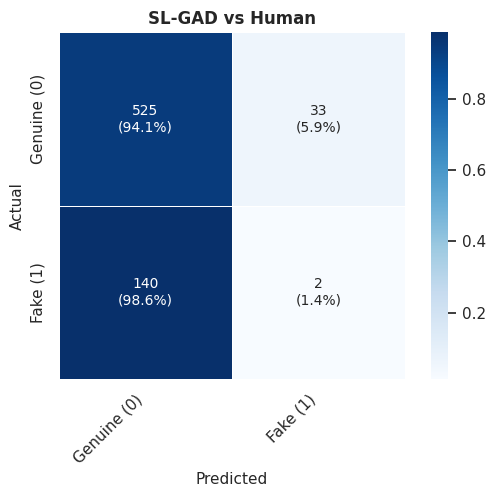

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'SL-GAD vs Human'}, xlabel='Predicted', ylabel='Actual'>)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_clean(y_true, y_pred,
                                labels=None,
                                label_names=None,
                                normalize='true',
                                figsize=(6,5),
                                cmap="Blues",
                                title="Confusion Matrix",
                                savepath=None):
    # compute raw confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_sum = cm.sum()
    if labels is None:
        labels = list(range(cm.shape[0]))
    if label_names is None:
        label_names = [str(l) for l in labels]

    # normalized matrix (row-wise by default)
    if normalize is None:
        cm_norm = None
    elif normalize == 'true':
        with np.errstate(all='ignore'):
            cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif normalize == 'pred':
        with np.errstate(all='ignore'):
            cm_norm = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :]
    elif normalize == 'all':
        cm_norm = cm.astype('float') / cm_sum
    else:
        raise ValueError("normalize must be one of {None, 'true', 'pred', 'all'}")

    # prepare annotations: "count\n(%)"
    annot = np.empty_like(cm).astype(object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            if cm_norm is None:
                annot[i, j] = f"{count:d}"
            else:
                annot[i, j] = f"{count:d}\n({cm_norm[i, j]:.1%})"

    # Style: use plain white background (no grid) to avoid interfering lines
    sns.set_style("white")
    sns.set_context("notebook")

    fig, ax = plt.subplots(figsize=figsize)

    # use heatmap (better cell rendering than imshow for matrices)
    # linewidths control thin separators between cells (set to 0 to remove)
    sns.heatmap(cm if cm_norm is None else cm_norm,
                ax=ax,
                cmap=cmap,
                cbar=True,
                annot=annot,
                fmt="",
                square=True,            # keeps cells square to avoid distortion lines
                linewidths=0.5,         # set to 0 to remove inner lines entirely
                linecolor="white",      # color of cell separators (if linewidths>0)
                annot_kws={"size":10, "weight":"medium"},
                xticklabels=label_names,
                yticklabels=label_names)

    # tidy labels
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="semibold")

    # rotate xticks
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # remove outer spines to look cleaner
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()

    if savepath:
        # save as PDF for crispiest results; PNG with high dpi also OK
        if savepath.lower().endswith('.pdf'):
            fig.savefig(savepath, bbox_inches='tight')
        else:
            fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

plot_confusion_matrix_clean(human["is_fake"], slgad["is_fake"],
                             labels=[0,1], label_names=["Genuine (0)","Fake (1)"],
                             normalize='true', title="SL-GAD vs Human", savepath="nb6/cm_slgad.pdf")


# SGDCTH RESULTS

In [ ]:
sgdcth_spammer_users = pd.read_csv("nb3/spammer_users.csv")
best_match_sgdcth = best_match.copy()
best_match_sgdcth["predicted_label"] = best_match_sgdcth["user_id"].isin(sgdcth_spammer_users["user_id"]).astype(int)

print(classification_report(ha["is_fake"], best_match_sgdcth["predicted_label"], digits=3))
print(confusion_matrix(ha["is_fake"], best_match_sgdcth["predicted_label"]))
print("Accuracy:", accuracy_score(ha["is_fake"], best_match_sgdcth["predicted_label"]))

              precision    recall  f1-score   support

           0      0.795     0.984     0.879       558
           1      0.000     0.000     0.000       142

    accuracy                          0.784       700
   macro avg      0.397     0.492     0.440       700
weighted avg      0.633     0.784     0.701       700

[[549   9]
 [142   0]]
Accuracy: 0.7842857142857143


In [ ]:
best_match_sgdcth.value_counts("predicted_label")

,count
predicted_label,
0,691
1,9


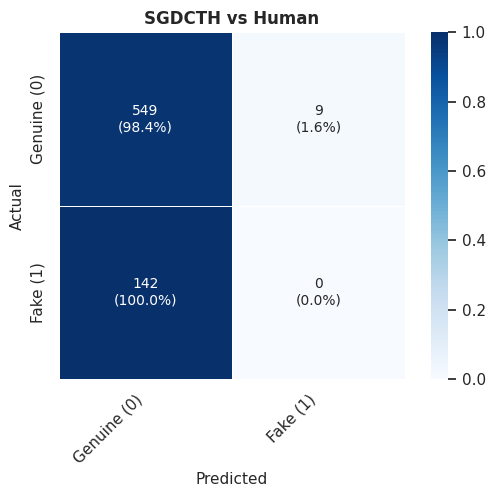

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'SGDCTH vs Human'}, xlabel='Predicted', ylabel='Actual'>)

In [ ]:
plot_confusion_matrix_clean(human["is_fake"], best_match_sgdcth["predicted_label"],
                             labels=[0,1], label_names=["Genuine (0)","Fake (1)"],
                             normalize='true', title="SGDCTH vs Human", savepath="nb6/cm_sgdcth.pdf")

# SLGAD-SGDCTH + CL RESULTS

In [ ]:
pred = pd.read_excel(MODEL_PRED)    # model preds

# Pastikan urutan row cocok
assert len(ha) == len(pred) == 700
assert (ha["text"] == pred["text"]).all()

y_true = ha["is_fake"].astype(int)       # ground truth manual
y_pred = pred["pred_label"].astype(int)  # pred model

print(classification_report(y_true, y_pred, digits=3))
print(confusion_matrix(y_true, y_pred))
print("Accuracy:", accuracy_score(y_true, y_pred))


              precision    recall  f1-score   support

           0      0.941     0.892     0.916       558
           1      0.649     0.782     0.709       142

    accuracy                          0.870       700
   macro avg      0.795     0.837     0.813       700
weighted avg      0.882     0.870     0.874       700

[[498  60]
 [ 31 111]]
Accuracy: 0.87


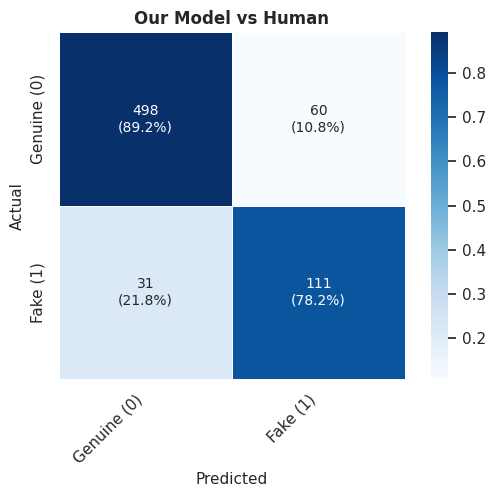

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Our Model vs Human'}, xlabel='Predicted', ylabel='Actual'>)

In [ ]:
plot_confusion_matrix_clean(y_true, y_pred,
                             labels=[0,1], label_names=["Genuine (0)","Fake (1)"],
                             normalize='true', title="Our Model vs Human", savepath="nb6/cm_our_model.pdf")

/tmp/ipython-input-1429957580.py:290: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1429957580.py:290: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1429957580.py:290: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1429957580.py:290: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packag

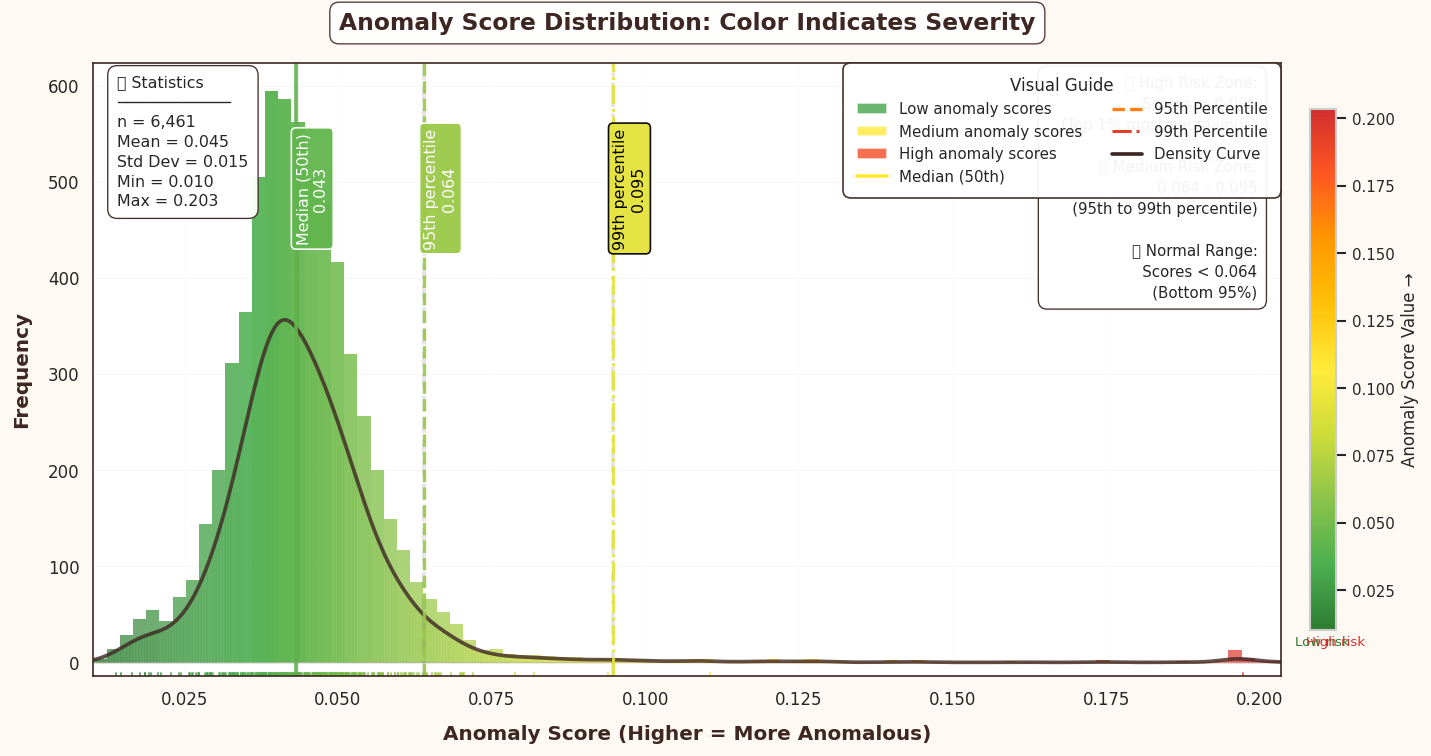


🎯 ANOMALY SCORE DISTRIBUTION - RISK ASSESSMENT
📊 Dataset Summary:
   Sample size: 6,461
   Score range: [0.0102, 0.2035]
   Mean score: 0.0448 ± 0.0154 (std)
-----------------------------------------------------------------
🔴 RISK ZONES (Color-coded in plot):
   🟢 NORMAL RANGE: Scores < 0.0640 (Bottom 95%)
   🟡 MEDIUM RISK: 0.0640 to 0.0947 (95th-99th percentile)
   🔴 HIGH RISK: Scores > 0.0947 (Top 1% - extreme anomalies)
-----------------------------------------------------------------
📈 Percentile Benchmarks:
   50th percentile: 0.0431
   95th percentile: 0.0640
   99th percentile: 0.0947
💡 Interpretation:
   • Color gradient indicates anomaly severity (green → yellow → red)
   • Red bars represent the most anomalous observations
   • Immediate attention needed for red zone observations
✅ Disimpan sebagai: nb6/anomaly_score_distribution.pdf


<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
import matplotlib.patheffects as pe

# Custom gradient color palette (hijau -> kuning -> merah)
# Semakin kanan (nilai tinggi) semakin merah
gradient_colors = ['#2E7D32', '#4CAF50', '#8BC34A', '#CDDC39', '#FFEB3B', '#FFC107', '#FF9800', '#FF5722', '#D32F2F']
custom_cmap = LinearSegmentedColormap.from_list('green_yellow_red', gradient_colors)

# Color scheme yang konsisten dengan tema merah untuk tinggi
colors = {
    'background': '#FEF9F3',  # Warm light background
    'hist_edge': 'none',      # No outline
    'rug': '#5D4037',         # Dark brown for rug plot
    'pct_50': '#2196F3',      # Blue for median
    'pct_95': '#FF9800',      # Orange for 95th
    'pct_99': '#F44336',      # Red for 99th
    'text': '#3E2723',        # Dark brown text
    'grid': '#E0E0E0',        # Light gray grid
    'highlight': '#9C27B0'    # Purple for density curve
}

# Set up the plot style
try:
    import seaborn as sns
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.1)
except Exception:
    plt.rcParams.update({
        'figure.facecolor': colors['background'],
        'axes.facecolor': colors['background'],
        'axes.edgecolor': colors['text'],
        'axes.labelcolor': colors['text'],
        'text.color': colors['text'],
        'grid.color': colors['grid'],
        'grid.alpha': 0.3,
        'xtick.color': colors['text'],
        'ytick.color': colors['text']
    })

# data: asumsi final_with_score['anomaly_score'] ada dan numeric
scores = final_with_score['anomaly_score'].dropna().to_numpy()

if scores.size == 0:
    raise ValueError("anomaly_score kosong — cek sumber datanya")

# percentiles we want to mark
pcts = [50, 95, 99]
pct_labels = ['Median (50th)', '95th percentile', '99th percentile']
pct_values = np.percentile(scores, pcts)

# Create figure
fig, ax = plt.subplots(figsize=(13, 6.5), dpi=120)
fig.patch.set_facecolor(colors['background'])

# Determine number of bins
n_bins = min(90, max(40, len(scores) // 25))

# Create histogram manually
counts, bin_edges = np.histogram(scores, bins=n_bins)

# Normalize bin CENTERS for gradient color mapping (not frequencies!)
# This ensures color is based on x-position (anomaly score value)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
norm_x = (bin_centers - bin_centers.min()) / (bin_centers.max() - bin_centers.min() + 1e-10)

# Create gradient-filled bars - color based on x-position (anomaly score)
max_count = counts.max()
for i in range(len(counts)):
    # Get color from gradient based on x-position (normalized bin center)
    # Use the normalized x-position directly
    color_value = norm_x[i]
    color = custom_cmap(color_value)

    # Optional: add slight transparency variation based on frequency
    alpha = 0.7 + 0.25 * (counts[i] / max_count)

    # Create the bar - NO EDGE COLOR
    rect = Rectangle((bin_edges[i], 0),
                     bin_edges[i+1] - bin_edges[i],
                     counts[i],
                     facecolor=color,
                     edgecolor='none',
                     linewidth=0,
                     alpha=alpha,
                     zorder=2,
                     joinstyle='round')
    ax.add_patch(rect)

# Set axis limits
ax.set_xlim(bin_edges[0], bin_edges[-1])
ax.set_ylim(0, max_count * 1.05)

# Create gradient colorbar for x-position (anomaly score values)
# Note: We create a dummy scalar mappable for the anomaly scores range
score_min, score_max = scores.min(), scores.max()
sm = ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=score_min, vmax=score_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label('Anomaly Score Value →', fontsize=10, fontweight='medium')
cbar.ax.tick_params(labelsize=9)

# Add color interpretation to colorbar
cbar.ax.text(0.5, -0.01, 'Low risk', transform=cbar.ax.transAxes,
             ha='center', va='top', fontsize=8, color='#2E7D32')
cbar.ax.text(1.0, -0.01, 'High risk', transform=cbar.ax.transAxes,
             ha='center', va='top', fontsize=8, color='#D32F2F')

# Vertical percentile lines - color them according to their position
pct_colors = [custom_cmap((pct_values[0] - score_min) / (score_max - score_min)),
              custom_cmap((pct_values[1] - score_min) / (score_max - score_min)),
              custom_cmap((pct_values[2] - score_min) / (score_max - score_min))]

line_styles = ['-', '--', '-.']
line_widths = [2.2, 2.0, 1.8]

for pct, val, label, color, ls, lw in zip(pcts, pct_values, pct_labels, pct_colors, line_styles, line_widths):
    # Add a subtle shadow for better visibility
    ax.axvline(val, color='black', linestyle=ls, linewidth=lw+0.5, alpha=0.1, zorder=3)
    # Main percentile line
    ax.axvline(val, color=color, linestyle=ls, linewidth=lw, alpha=0.9, zorder=4)

    # Annotations with color matching the line
    y_pos = max_count * 0.83
    # Determine text color (white for dark colors, black for light colors)
    # Simple brightness calculation
    brightness = sum(color[:3]) / 3
    text_color = 'white' if brightness < 0.6 else 'black'

    ax.annotate(f'{label}\n{val:.3f}',
                xy=(val, y_pos),
                xytext=(10, 0),
                textcoords='offset points',
                rotation=90,
                fontsize=9.5,
                fontweight='medium',
                color=text_color,
                ha='center',
                va='center',
                bbox=dict(boxstyle='round,pad=0.3',
                         facecolor=color,
                         edgecolor='white' if brightness < 0.6 else 'black',
                         alpha=0.95,
                         linewidth=1.0),
                zorder=5)

# Enhanced rug plot with gradient matching the histogram
ymin, ymax = ax.get_ylim()
tick_y = -0.018 * ymax

# Sample points for rug plot
sample_size = min(400, len(scores))
if len(scores) > sample_size:
    sample_indices = np.linspace(0, len(scores)-1, sample_size, dtype=int)
    sample_scores = scores[sample_indices]
else:
    sample_scores = scores

# Rug plot with gradient colors based on score value
norm_sample_scores = (sample_scores - score_min) / (score_max - score_min + 1e-10)
for score, norm_score in zip(sample_scores, norm_sample_scores):
    rug_color = custom_cmap(norm_score)
    ax.plot([score, score], [tick_y, tick_y - 0.008*ymax],
            color=rug_color,
            linewidth=1.2,
            alpha=0.7,
            zorder=1)

# Add density curve with gradient fill
try:
    from scipy import stats
    if len(scores) > 10:
        kde = stats.gaussian_kde(scores, bw_method='scott')
        x_kde = np.linspace(score_min, score_max, 400)
        y_kde = kde(x_kde)
        y_kde = y_kde / y_kde.max() * max_count * 0.6

        # Create gradient fill under curve
        for i in range(len(x_kde)-1):
            fill_color = custom_cmap((x_kde[i] - score_min) / (score_max - score_min))
            ax.fill_between([x_kde[i], x_kde[i+1]], [y_kde[i], y_kde[i+1]],
                           alpha=0.15, color=fill_color, zorder=2)

        # Plot the curve
        ax.plot(x_kde, y_kde, color=colors['text'], linewidth=2.2, alpha=0.8, zorder=3, label='Density Curve')
except:
    pass

# Create informative legend
legend_elements = [
    mpatches.Patch(facecolor=custom_cmap(0.1), alpha=0.8, label='Low anomaly scores'),
    mpatches.Patch(facecolor=custom_cmap(0.5), alpha=0.8, label='Medium anomaly scores'),
    mpatches.Patch(facecolor=custom_cmap(0.9), alpha=0.8, label='High anomaly scores'),
    plt.Line2D([0], [0], color=custom_cmap(0.5), linewidth=2.2, linestyle='-', label='Median (50th)'),
    plt.Line2D([0], [0], color=custom_cmap(0.8), linewidth=2.0, linestyle='--', label='95th Percentile'),
    plt.Line2D([0], [0], color=custom_cmap(0.95), linewidth=1.8, linestyle='-.', label='99th Percentile'),
]

if len(scores) > 10:
    legend_elements.append(plt.Line2D([0], [0], color=colors['text'], linewidth=2.2, label='Density Curve'))

legend = ax.legend(handles=legend_elements, loc='upper right',
                   frameon=True,
                   framealpha=0.95,
                   edgecolor=colors['text'],
                   facecolor='white',
                   fontsize=9,
                   title='Visual Guide',
                   title_fontsize=10,
                   ncol=2)
legend.get_frame().set_boxstyle('round,pad=0.5')

# Labels & title with emphasis on the gradient meaning
ax.set_xlabel("Anomaly Score (Higher = More Anomalous)", fontsize=12, fontweight='semibold', labelpad=10, color=colors['text'])
ax.set_ylabel("Frequency", fontsize=12, fontweight='semibold', labelpad=10, color=colors['text'])

# Title with color gradient text effect
title_text = ax.set_title("Anomaly Score Distribution: Color Indicates Severity",
                          fontsize=14, fontweight='bold', pad=20,
                          color=colors['text'])
title_text.set_bbox(dict(facecolor='white', alpha=0.9, edgecolor=colors['text'],
                        boxstyle='round,pad=0.4', linewidth=0.8))

# Add risk interpretation guide
risk_text = (f"🔴 High Risk Zone:\n"
             f"   Scores > {pct_values[2]:.3f}\n"
             f"   (Top 1% most anomalous)\n\n"
             f"🟡 Medium Risk Zone:\n"
             f"   {pct_values[1]:.3f} - {pct_values[2]:.3f}\n"
             f"   (95th to 99th percentile)\n\n"
             f"🟢 Normal Range:\n"
             f"   Scores < {pct_values[1]:.3f}\n"
             f"   (Bottom 95%)")

risk_box = ax.text(0.98, 0.98, risk_text, transform=ax.transAxes,
                   fontsize=9,
                   fontweight='medium',
                   verticalalignment='top',
                   horizontalalignment='right',
                   linespacing=1.5,
                   bbox=dict(boxstyle='round,pad=0.6',
                            facecolor='white',
                            edgecolor=colors['text'],
                            alpha=0.95,
                            linewidth=0.8),
                   zorder=5)

# Add statistics box
stats_text = (f"📊 Statistics\n"
              f"────────────\n"
              f"n = {len(scores):,}\n"
              f"Mean = {np.mean(scores):.3f}\n"
              f"Std Dev = {np.std(scores):.3f}\n"
              f"Min = {np.min(scores):.3f}\n"
              f"Max = {np.max(scores):.3f}")

stats_box = ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                    fontsize=9.5,
                    fontweight='medium',
                    verticalalignment='top',
                    linespacing=1.4,
                    bbox=dict(boxstyle='round,pad=0.6',
                             facecolor='white',
                             edgecolor=colors['text'],
                             alpha=0.95,
                             linewidth=0.8),
                    zorder=5)

# Grid & ticks - clean and subtle
ax.grid(axis='y', alpha=0.15, linestyle='-', linewidth=0.6, zorder=0)
ax.grid(axis='x', alpha=0.08, linestyle='-', linewidth=0.4, zorder=0)
ax.tick_params(axis='both', which='major', labelsize=10, length=5, width=1, zorder=5)

# Style the spines
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color(colors['text'])
    spine.set_zorder(5)

# Set bottom limit to accommodate rug plot
ax.set_ylim(bottom=tick_y - 0.005*ymax)

# Add subtle horizontal line at y=0
ax.axhline(y=0, color=colors['text'], linewidth=0.8, alpha=0.3, zorder=1)

plt.tight_layout()
plt.show()

# Print comprehensive summary
print("\n" + "=" * 65)
print("🎯 ANOMALY SCORE DISTRIBUTION - RISK ASSESSMENT")
print("=" * 65)
print(f"📊 Dataset Summary:")
print(f"   Sample size: {len(scores):,}")
print(f"   Score range: [{score_min:.4f}, {score_max:.4f}]")
print(f"   Mean score: {np.mean(scores):.4f} ± {np.std(scores):.4f} (std)")
print("-" * 65)
print(f"🔴 RISK ZONES (Color-coded in plot):")
print(f"   🟢 NORMAL RANGE: Scores < {pct_values[1]:.4f} (Bottom 95%)")
print(f"   🟡 MEDIUM RISK: {pct_values[1]:.4f} to {pct_values[2]:.4f} (95th-99th percentile)")
print(f"   🔴 HIGH RISK: Scores > {pct_values[2]:.4f} (Top 1% - extreme anomalies)")
print("-" * 65)
print(f"📈 Percentile Benchmarks:")
for pct, val in zip(pcts, pct_values):
    print(f"   {pct}th percentile: {val:.4f}")
print("=" * 65)
print(f"💡 Interpretation:")
print(f"   • Color gradient indicates anomaly severity (green → yellow → red)")
print(f"   • Red bars represent the most anomalous observations")
print(f"   • Immediate attention needed for red zone observations")
print("=" * 65)

output_filename = "nb6/anomaly_score_distribution"

# Format PDF (vector, bisa di-zoom tanpa pecah)
plt.savefig(f"{output_filename}.pdf", format='pdf', bbox_inches='tight')
print(f"✅ Disimpan sebagai: {output_filename}.pdf")